In [1]:
import pandas as pd
import numpy as np

In [2]:
df_norm_counts = pd.read_csv("../results/GSE95640_DeSEQ2_normalized_counts.csv", index_col=0)
df_norm_counts

,GSM2520157,GSM2520158,GSM2520159,GSM2520160,GSM2520161,GSM2520162,GSM2520163,GSM2520164,GSM2520165,GSM2520166,...,GSM2520529,GSM2520530,GSM2520531,GSM2520532,GSM2520533,GSM2520534,GSM2520535,GSM2520536,GSM2520537,GSM2520538
GeneID,,,,,,,,,,,,,,,,,,,,,
100287102,21.005022,2.253288,9.606387,1.787645,2.985084,18.561131,4.279128,1.987068,7.709543,2.399610,...,1.001034,6.444927,6.151350,4.607232,5.725350,4.194643,2.588963,2.837753,7.136887,4.514742
653635,573.437111,482.203642,599.089232,362.891850,396.269921,491.324046,491.029974,419.271322,651.105935,295.951870,...,301.311342,479.789033,343.108653,310.220309,350.200585,442.954275,325.346371,303.639540,202.687600,558.323045
102466751,13.303181,11.266440,19.212774,8.938223,12.686608,13.101975,14.976949,14.903009,20.325158,9.598439,...,8.008275,20.766988,13.669667,6.910848,12.404925,24.328928,5.177926,8.513258,7.136887,15.049139
107985730,0.700167,0.000000,0.873308,0.000000,0.746271,1.091831,0.000000,0.993534,0.700868,0.799870,...,0.000000,0.716103,0.683483,1.535744,0.954225,0.838929,0.000000,0.945918,1.427377,0.752457
100302278,0.000000,0.000000,0.873308,0.000000,0.000000,0.000000,0.000000,0.000000,0.700868,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.945918,1.427377,0.752457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4541,65218.493984,53285.755684,86956.142713,88890.626715,58519.589752,93704.230291,96074.988846,86339.092872,130099.236104,81206.793640,...,107583.164659,81885.665935,88575.344297,116805.625222,114593.837604,164748.788991,112876.205083,124964.224368,104541.125575,67572.137611
4556,5002.696163,3511.749418,7082.527216,7030.806131,4890.314115,7153.678115,7319.448977,5973.126044,9628.518126,6954.868955,...,8242.516914,6163.498821,7023.475145,8175.533749,8248.321125,11225.702951,7444.995078,9371.205374,6320.427417,6075.337287
4519,177973.454113,166229.565643,227802.370435,242588.732369,135318.342320,270049.165182,262076.283209,247025.323967,322034.612635,261377.493147,...,234232.029724,289490.380672,215474.968310,282656.006345,274298.663315,397946.597448,257454.264135,314770.152301,286750.141182,200003.053127


In [3]:
df_sample_annot = pd.read_csv("../results/GSE95640_sample_annotation.csv", index_col=0)
df_sample_annot

,sample_name,group,group_0_1
B00EVBV,GSM2520157,time: CID1 is for the baseline without LCD,0
B00EVBY,GSM2520158,time: CID1 is for the baseline without LCD,0
B00EVC0,GSM2520159,time: CID1 is for the baseline without LCD,0
B00EVC2,GSM2520160,time: CID1 is for the baseline without LCD,0
B00EVC4,GSM2520161,time: CID1 is for the baseline without LCD,0
...,...,...,...
B00EWA9,GSM2520534,time: CID2 is after 8 weeks of LCD,1
B00EWAE,GSM2520535,time: CID2 is after 8 weeks of LCD,1
B00EWAF,GSM2520536,time: CID2 is after 8 weeks of LCD,1
B00EWEV,GSM2520537,time: CID1 is for the baseline without LCD,0


In [4]:
df_gene_annot = pd.read_csv('../data/Human.GRCh38.p13.annot.tsv', sep='\t', index_col = None, header=0, low_memory=False)
df_gene_annot

,GeneID,Symbol,Description,Synonyms,GeneType,EnsemblGeneID,Status,ChrAcc,ChrStart,ChrStop,Orientation,Length,GOFunctionID,GOProcessID,GOComponentID,GOFunction,GOProcess,GOComponent
0,100287102,DDX11L1,DEAD/H-box helicase 11 like 1 (pseudogene),NaN,pseudo,ENSG00000290825,active,NC_000001.11,11874,14409,positive,1652,NaN,NaN,NaN,NaN,NaN,NaN
1,653635,WASH7P,"WASP family homolog 7, pseudogene",FAM39F|WASH5P,pseudo,NaN,active,NC_000001.11,14362,29370,negative,1769,NaN,NaN,NaN,NaN,NaN,NaN
2,102466751,MIR6859-1,microRNA 6859-1,hsa-mir-6859-1,ncRNA,ENSG00000278267,active,NC_000001.11,17369,17436,negative,68,NaN,NaN,NaN,NaN,NaN,NaN
3,107985730,MIR1302-2HG,MIR1302-2 host gene,NaN,ncRNA,NaN,active,NC_000001.11,29926,31295,positive,538,NaN,NaN,NaN,NaN,NaN,NaN
4,100302278,MIR1302-2,microRNA 1302-2,MIRN1302-2|hsa-mir-1302-2,ncRNA,ENSG00000284332,active,NC_000001.11,30366,30503,positive,138,NaN,GO:0035195,NaN,NaN,miRNA-mediated gene silencing,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39371,4541,ND6,NADH dehydrogenase subunit 6,MTND6,protein-coding,NaN,active,NC_012920.1,14149,14673,negative,525,GO:0008137,GO:0006120///GO:0009060///GO:0032981///GO:0035...,GO:0005739///GO:0005743///GO:0005747,NADH dehydrogenase (ubiquinone) activity,"mitochondrial electron transport, NADH to ubiq...",mitochondrion///mitochondrial inner membrane//...
39372,4556,TRNE,tRNA-Glu,MTTE,tRNA,NaN,active,NC_012920.1,14674,14742,negative,69,NaN,NaN,NaN,NaN,NaN,NaN
39373,4519,CYTB,cytochrome b,MTCYB,protein-coding,NaN,active,NC_012920.1,14747,15887,positive,1141,GO:0008121///GO:0046872,GO:0006122///GO:0045333///GO:1902600,GO:0005739///GO:0005743///GO:0005750///GO:0016020,ubiquinol-cytochrome-c reductase activity///me...,"mitochondrial electron transport, ubiquinol to...",mitochondrion///mitochondrial inner membrane//...
39374,4576,TRNT,tRNA-Thr,MTTT,tRNA,NaN,active,NC_012920.1,15888,15953,positive,66,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Import required libraries for differential expression analysis
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

print("Starting differential expression analysis using existing dataframes:")
print(f"- df_norm_counts shape: {df_norm_counts.shape}")
print(f"- df_sample_annot shape: {df_sample_annot.shape}")
print(f"- df_gene_annot shape: {df_gene_annot.shape}")

Starting differential expression analysis using existing dataframes:
- df_norm_counts shape: (39376, 382)
- df_sample_annot shape: (382, 3)
- df_gene_annot shape: (39376, 18)


In [6]:
# Prepare sample groups for differential expression analysis
print("Preparing sample groups...")

# Create mapping from sample_name to group
sample_to_group = df_sample_annot.set_index('sample_name')['group_0_1'].to_dict()

# Get samples that exist in both normalized counts and sample annotation
available_samples = df_norm_counts.columns.intersection(df_sample_annot['sample_name'])
print(f"Samples available in both datasets: {len(available_samples)}")

# Filter normalized counts to common samples
df_counts_analysis = df_norm_counts[available_samples]

# Create group assignments
baseline_samples = [s for s in available_samples if sample_to_group[s] == 0]
treated_samples = [s for s in available_samples if sample_to_group[s] == 1]

print(f"Baseline samples (group 0): {len(baseline_samples)}")
print(f"Treated samples (group 1): {len(treated_samples)}")

# Get expression data for each group
baseline_data = df_counts_analysis[baseline_samples]
treated_data = df_counts_analysis[treated_samples]

print(f"Baseline data shape: {baseline_data.shape}")
print(f"Treated data shape: {treated_data.shape}")

Preparing sample groups...
Samples available in both datasets: 382
Baseline samples (group 0): 191
Treated samples (group 1): 191
Baseline data shape: (39376, 191)
Treated data shape: (39376, 191)


In [7]:
# Prepare data for DESeq2 analysis
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

print("Setting up DESeq2 analysis...")

# Convert normalized counts back to pseudo raw counts for DESeq2
# DESeq2 expects raw counts, so we'll scale up the normalized counts
scale_factor = 1000
pseudo_counts = (df_counts_analysis * scale_factor).round().astype(int)

# Transpose to get samples as rows (required by pyDESeq2)
counts_matrix = pseudo_counts.T

print(f"Pseudo counts matrix shape (samples x genes): {counts_matrix.shape}")

# Create metadata DataFrame
metadata = pd.DataFrame({
    'sample_id': available_samples,
    'condition': [sample_to_group[s] for s in available_samples]
})
metadata['condition'] = metadata['condition'].map({0: 'baseline', 1: 'treated'})
metadata.set_index('sample_id', inplace=True)

print(f"Metadata shape: {metadata.shape}")
print("Condition distribution:")
print(metadata['condition'].value_counts())

# Ensure metadata index matches counts matrix index
metadata = metadata.loc[counts_matrix.index]

print("Data prepared for DESeq2 analysis")

Setting up DESeq2 analysis...
Pseudo counts matrix shape (samples x genes): (382, 39376)
Metadata shape: (382, 1)
Condition distribution:
condition
baseline    191
treated     191
Name: count, dtype: int64
Data prepared for DESeq2 analysis


In [8]:
# Run DESeq2 analysis
print("Running DESeq2 differential expression analysis...")

try:
    # Create DESeqDataSet
    dds = DeseqDataSet(
        counts=counts_matrix,
        metadata=metadata,
        design_factors="condition",
        ref_level=["condition", "baseline"]
    )
    
    print("DESeqDataSet created successfully")
    
    # Run DESeq2 analysis
    print("Running DESeq2...")
    dds.deseq2()
    print("DESeq2 analysis completed")
    
    # Get statistical results
    print("Computing statistical results...")
    stat_res = DeseqStats(dds, contrast=["condition", "treated", "baseline"])
    stat_res.summary()
    
    # Extract results
    deseq2_results = stat_res.results_df.copy()
    
    print(f"DESeq2 results shape: {deseq2_results.shape}")
    print("\nDESeq2 results columns:")
    print(deseq2_results.columns.tolist())
    
    print("\nFirst few DESeq2 results:")
    print(deseq2_results.head())
    
    # Add gene_id column for easier merging
    deseq2_results.reset_index(inplace=True)
    deseq2_results.rename(columns={'index': 'gene_id'}, inplace=True)
    
    print("DESeq2 analysis completed successfully!")
    
except Exception as e:
    print(f"Error running DESeq2: {e}")
    print("This might be due to data format issues with pyDESeq2")
    raise

Running DESeq2 differential expression analysis...
DESeqDataSet created successfully
Running DESeq2...
Using None as control genes, passed at DeseqDataSet initialization
DESeqDataSet created successfully
Running DESeq2...
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.25 seconds.

... done in 0.25 seconds.

Fitting dispersions...
Fitting dispersions...
... done in 3.15 seconds.

Fitting dispersion trend curve...
... done in 3.15 seconds.

Fitting dispersion trend curve...
... done in 0.46 seconds.

Fitting MAP dispersions...
... done in 0.46 seconds.

Fitting MAP dispersions...
... done in 4.16 seconds.

Fitting LFCs...
... done in 4.16 seconds.

Fitting LFCs...
... done in 3.30 seconds.

Calculating cook's distance...
... done in 3.30 seconds.

Calculating cook's distance...
... done in 0.53 seconds.

Replacing 7507 outlier genes.

... done in 0.53 seconds.

Replacing 7507 outlier genes.

Fitting dispersions...
... done in 0.19 seconds.

Fitting MAP dispersions...
Fitting dispersions...
... done in 0.19 seconds.

Fitting MAP dispersions...
... done in 0.15 seconds.

Fitting LFCs...
... done in 0.15 seconds.

Fitting LFCs...
... done in 1.57 seconds.

Running Wald tests...
... done in 1.57 seconds.

Running Wald

DESeq2 analysis completed
Computing statistical results...
Log2 fold change & Wald test p-value: condition treated vs baseline
               baseMean  log2FoldChange     lfcSE      stat        pvalue  \
GeneID                                                                      
100287102  6.554542e+03       -0.194638  0.100690 -1.933039  5.323143e-02   
653635     3.421119e+05        0.061290  0.050958  1.202752  2.290722e-01   
102466751  1.009878e+04        0.187805  0.067334  2.789146  5.284718e-03   
107985730  5.531296e+02       -0.376069  0.443386 -0.848175  3.963406e-01   
100302278  1.700084e+02       -0.488108  0.990818 -0.492632  6.222730e-01   
...                 ...             ...       ...       ...           ...   
4541       9.581418e+07       -0.156821  0.049399 -3.174578  1.500548e-03   
4556       7.597892e+06       -0.246617  0.047056 -5.240899  1.597958e-07   
4519       2.648035e+08       -0.257961  0.052639 -4.900589  9.554952e-07   
4576       6.969891e+05   

... done in 0.95 seconds.



In [9]:
# Extract and annotate DESeq2 results
print("Processing DESeq2 results...")

# The DESeq2 results already contain gene IDs and all necessary columns
print("DESeq2 results summary:")
print(f"Total genes analyzed: {len(deseq2_results)}")
print(f"Genes with p-value < 0.05: {(deseq2_results['pvalue'] < 0.05).sum()}")
print(f"Genes with FDR < 0.05: {(deseq2_results['padj'] < 0.05).sum()}")

# Add gene annotations
print("\nAdding gene annotations...")

# Check data types of GeneID columns
print(f"DESeq2 results GeneID dtype: {deseq2_results['GeneID'].dtype}")
print(f"Gene annotation GeneID dtype: {df_gene_annot['GeneID'].dtype}")

# Convert both GeneID columns to string for consistent merging
deseq2_results_copy = deseq2_results.copy()
deseq2_results_copy['GeneID'] = deseq2_results_copy['GeneID'].astype(str)

df_gene_annot_copy = df_gene_annot.copy()
df_gene_annot_copy['GeneID'] = df_gene_annot_copy['GeneID'].astype(str)

# Now merge with consistent data types
deseq2_with_annot = deseq2_results_copy.merge(
    df_gene_annot_copy,
    on='GeneID',  # Both have GeneID column
    how='left'
)

print(f"Results with annotations shape: {deseq2_with_annot.shape}")

# Display basic statistics
print(f"\nDESeq2 Results Statistics:")
print(f"Mean log2FoldChange: {deseq2_results['log2FoldChange'].mean():.3f}")
print(f"Std log2FoldChange: {deseq2_results['log2FoldChange'].std():.3f}")
print(f"Mean baseMean: {deseq2_results['baseMean'].mean():.1f}")

print(f"\nFirst few annotated results:")
display_cols = ['GeneID', 'log2FoldChange', 'pvalue', 'padj', 'baseMean']

# Add gene symbol if available
symbol_cols = ['Gene_Symbol', 'gene_symbol', 'Symbol', 'symbol', 'Gene_Name', 'gene_name']
for col in symbol_cols:
    if col in deseq2_with_annot.columns:
        display_cols.insert(1, col)
        break

print(deseq2_with_annot[display_cols].head())

Processing DESeq2 results...
DESeq2 results summary:
Total genes analyzed: 39376
Genes with p-value < 0.05: 11062
Genes with FDR < 0.05: 8755

Adding gene annotations...
DESeq2 results GeneID dtype: object
Gene annotation GeneID dtype: int64
Results with annotations shape: (39376, 24)

DESeq2 Results Statistics:
Mean log2FoldChange: 0.068
Std log2FoldChange: 1.369
Mean baseMean: 575927.9

First few annotated results:
      GeneID       Symbol  log2FoldChange    pvalue      padj       baseMean
0  100287102      DDX11L1       -0.194638  0.053231  0.116475    6554.542486
1     653635       WASH7P        0.061290  0.229072  0.363471  342111.924866
2  102466751    MIR6859-1        0.187805  0.005285  0.017097   10098.780045
3  107985730  MIR1302-2HG       -0.376069  0.396341       NaN     553.129558
4  100302278    MIR1302-2       -0.488108  0.622273       NaN     170.008382


In [10]:
# Filter for significant differentially expressed genes
print("Filtering significant genes...")

# Apply significance filters: p-value < 0.05 and |log2FC| > 1
significant_genes = deseq2_with_annot[
    (deseq2_with_annot['pvalue'] < 0.05) & 
    (abs(deseq2_with_annot['log2FoldChange']) > 1)
]

print(f"Significant genes (p < 0.05, |log2FC| > 1): {len(significant_genes)}")

# Also filter by FDR
significant_genes_fdr = deseq2_with_annot[
    (deseq2_with_annot['padj'] < 0.05) & 
    (abs(deseq2_with_annot['log2FoldChange']) > 1)
]

print(f"Significant genes (FDR < 0.05, |log2FC| > 1): {len(significant_genes_fdr)}")

# Separate upregulated and downregulated genes
upregulated = significant_genes[significant_genes['log2FoldChange'] > 1]
downregulated = significant_genes[significant_genes['log2FoldChange'] < -1]

print(f"\nGene regulation summary:")
print(f"Upregulated genes (log2FC > 1): {len(upregulated)}")
print(f"Downregulated genes (log2FC < -1): {len(downregulated)}")

# Sort by significance (p-value)
significant_genes_sorted = significant_genes.sort_values('pvalue')

print(f"\nTop 10 most significant differentially expressed genes:")
print(significant_genes_sorted[display_cols].head(10))

# Save results
print(f"\nSaving results...")
deseq2_with_annot.to_csv("../results/DESeq2_all_results.csv", index=False)
significant_genes.to_csv("../results/DESeq2_significant_genes.csv", index=False)

print("Results saved to:")
print("- ../results/DESeq2_all_results.csv")
print("- ../results/DESeq2_significant_genes.csv")

Filtering significant genes...
Significant genes (p < 0.05, |log2FC| > 1): 576
Significant genes (FDR < 0.05, |log2FC| > 1): 80

Gene regulation summary:
Upregulated genes (log2FC > 1): 354
Downregulated genes (log2FC < -1): 222

Top 10 most significant differentially expressed genes:
          GeneID        Symbol  log2FoldChange        pvalue          padj  \
22094       9415         FADS2       -1.763532  5.203351e-73  1.211861e-68   
31176        230         ALDOC       -1.235490  3.517544e-66  4.096180e-62   
13749     221262      CCDC162P       -1.252972  4.293628e-59  3.333286e-55   
20692       6319           SCD       -1.875106  1.049648e-56  6.111574e-53   
22092       3992         FADS1       -1.551051  9.697503e-53  4.517097e-49   
9736       79071        ELOVL6       -1.525736  2.201496e-50  8.545472e-47   
38904     286411     LINC00632       -1.221395  7.055636e-50  2.347511e-46   
22852  105369488  LOC105369488       -1.838154  2.030957e-48  3.941749e-45   
10878     28

In [11]:
deseq2_with_annot


,GeneID,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol,Description,Synonyms,...,ChrStart,ChrStop,Orientation,Length,GOFunctionID,GOProcessID,GOComponentID,GOFunction,GOProcess,GOComponent
0,100287102,6.554542e+03,-0.194638,0.100690,-1.933039,5.323143e-02,1.164750e-01,DDX11L1,DEAD/H-box helicase 11 like 1 (pseudogene),NaN,...,11874,14409,positive,1652,NaN,NaN,NaN,NaN,NaN,NaN
1,653635,3.421119e+05,0.061290,0.050958,1.202752,2.290722e-01,3.634709e-01,WASH7P,"WASP family homolog 7, pseudogene",FAM39F|WASH5P,...,14362,29370,negative,1769,NaN,NaN,NaN,NaN,NaN,NaN
2,102466751,1.009878e+04,0.187805,0.067334,2.789146,5.284718e-03,1.709697e-02,MIR6859-1,microRNA 6859-1,hsa-mir-6859-1,...,17369,17436,negative,68,NaN,NaN,NaN,NaN,NaN,NaN
3,107985730,5.531296e+02,-0.376069,0.443386,-0.848175,3.963406e-01,NaN,MIR1302-2HG,MIR1302-2 host gene,NaN,...,29926,31295,positive,538,NaN,NaN,NaN,NaN,NaN,NaN
4,100302278,1.700084e+02,-0.488108,0.990818,-0.492632,6.222730e-01,NaN,MIR1302-2,microRNA 1302-2,MIRN1302-2|hsa-mir-1302-2,...,30366,30503,positive,138,NaN,GO:0035195,NaN,NaN,miRNA-mediated gene silencing,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39371,4541,9.581418e+07,-0.156821,0.049399,-3.174578,1.500548e-03,5.862733e-03,ND6,NADH dehydrogenase subunit 6,MTND6,...,14149,14673,negative,525,GO:0008137,GO:0006120///GO:0009060///GO:0032981///GO:0035...,GO:0005739///GO:0005743///GO:0005747,NADH dehydrogenase (ubiquinone) activity,"mitochondrial electron transport, NADH to ubiq...",mitochondrion///mitochondrial inner membrane//...
39372,4556,7.597892e+06,-0.246617,0.047056,-5.240899,1.597958e-07,1.857108e-06,TRNE,tRNA-Glu,MTTE,...,14674,14742,negative,69,NaN,NaN,NaN,NaN,NaN,NaN
39373,4519,2.648035e+08,-0.257961,0.052639,-4.900589,9.554952e-07,9.172912e-06,CYTB,cytochrome b,MTCYB,...,14747,15887,positive,1141,GO:0008121///GO:0046872,GO:0006122///GO:0045333///GO:1902600,GO:0005739///GO:0005743///GO:0005750///GO:0016020,ubiquinol-cytochrome-c reductase activity///me...,"mitochondrial electron transport, ubiquinol to...",mitochondrion///mitochondrial inner membrane//...
39374,4576,6.969891e+05,-0.329584,0.059863,-5.505645,3.678199e-08,4.928955e-07,TRNT,tRNA-Thr,MTTT,...,15888,15953,positive,66,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df_sig_lfc_fdr = deseq2_with_annot[
    (deseq2_with_annot['padj'] < 0.05) & 
    (abs(deseq2_with_annot['log2FoldChange']) > 1)
]
df_sig_lfc_fdr.to_csv("../results/80_DESeq2_significant_genes_lfc_fdr.csv", index=False)
df_sig_lfc_fdr

,GeneID,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol,Description,Synonyms,...,ChrStart,ChrStop,Orientation,Length,GOFunctionID,GOProcessID,GOComponentID,GOFunction,GOProcess,GOComponent
315,126767,1.652589e+04,-1.740409,0.222229,-7.831608,4.816703e-15,2.230239e-13,AADACL3,arylacetamide deacetylase like 3,NaN,...,12716110,12728760,positive,4055,GO:0052689,NaN,GO:0016020,carboxylic ester hydrolase activity,NaN,membrane
1684,1301,1.734100e+05,-1.392270,0.155077,-8.977954,2.758489e-19,2.170446e-17,COL11A1,collagen type XI alpha 1 chain,CO11A1|COLL6|DFNA37|STL2,...,102876467,103108580,negative,8160,GO:0005201///GO:0008201///GO:0030020///GO:0030...,GO:0001502///GO:0001503///GO:0002063///GO:0006...,GO:0005576///GO:0005592///GO:0005615///GO:0005...,extracellular matrix structural constituent///...,cartilage condensation///ossification///chondr...,extracellular region///collagen type XI trimer...
3116,1118,1.297272e+06,1.140645,0.165250,6.902558,5.107430e-12,1.433157e-10,CHIT1,chitinase 1,CHI3|CHIT|CHITD,...,203216079,203229673,negative,2476,GO:0004553///GO:0004568///GO:0008061///GO:0008843,GO:0000272///GO:0006032///GO:0006955///GO:0009...,GO:0005576///GO:0005615///GO:0005764///GO:0035...,"hydrolase activity, hydrolyzing O-glycosyl com...",polysaccharide catabolic process///chitin cata...,extracellular region///extracellular space///l...
4212,105374435,1.268380e+04,-1.145530,0.130653,-8.767738,1.822915e-18,1.330899e-16,LOC105374435,uncharacterized LOC105374435,NaN,...,30823502,30835430,positive,2099,NaN,NaN,NaN,NaN,NaN,NaN
4611,56287,2.706438e+03,-1.428250,0.300370,-4.754968,1.984777e-06,1.751628e-05,GKN1,gastrokine 1,AMP18|BRICD1|CA11|FOV|foveolin,...,68974573,68980980,positive,820,GO:0003674///GO:0005515///GO:0008083,GO:0007165///GO:0007586///GO:0008284///GO:0042...,GO:0005576///GO:0005615///GO:0005794///GO:0030141,molecular_function///protein binding///growth ...,signal transduction///digestion///positive reg...,extracellular region///extracellular space///G...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36995,440799,3.271017e+04,-1.050278,0.116615,-9.006362,2.130054e-19,1.716573e-17,P2RX6P,purinergic receptor P2X 6 pseudogene,NaN,...,21042392,21044249,negative,124,NaN,NaN,NaN,NaN,NaN,NaN
37830,25878,2.205865e+06,-1.096929,0.098469,-11.139882,8.022589e-29,2.617306e-26,MXRA5,matrix remodeling associated 5,NaN,...,3308565,3346652,negative,9804,GO:0005201,GO:0071559,GO:0005576///GO:0062023///GO:0070062,extracellular matrix structural constituent,response to transforming growth factor beta,extracellular region///collagen-containing ext...
37890,109729169,1.767810e+04,1.472530,0.249295,5.906786,3.488464e-09,5.836662e-08,LINC02154,long intergenic non-protein coding RNA 2154,NaN,...,13266048,13303452,negative,1421,NaN,NaN,NaN,NaN,NaN,NaN
38221,105373202,7.278099e+04,-1.285654,0.126560,-10.158429,3.039345e-24,5.020308e-22,LOC105373202,uncharacterized LOC105373202,NaN,...,50979079,50992526,positive,1159,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
significant_genes

,GeneID,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol,Description,Synonyms,...,ChrStart,ChrStop,Orientation,Length,GOFunctionID,GOProcessID,GOComponentID,GOFunction,GOProcess,GOComponent
135,105378598,12.413825,7.056994,2.897162,2.435830,0.014858,NaN,LOC105378598,uncharacterized LOC105378598,NaN,...,2767822,2784745,positive,4691,NaN,NaN,NaN,NaN,NaN,NaN
138,140625,31.490268,-7.000034,2.228135,-3.141656,0.001680,NaN,ACTRT2,actin related protein T2,ARPM2|ARPT2|Arp-T2|HARPM2,...,3021467,3022903,positive,1437,NaN,NaN,GO:0005737///GO:0005856,NaN,NaN,cytoplasm///cytoskeleton
144,105378605,35.005092,7.149236,1.882133,3.798475,0.000146,NaN,LOC105378605,uncharacterized LOC105378605,NaN,...,3210740,3214473,negative,3292,NaN,NaN,NaN,NaN,NaN,NaN
210,105376692,9.914416,6.146069,2.892308,2.124971,0.033589,NaN,LOC105376692,NaN,NaN,...,7235640,7240139,negative,2326,NaN,NaN,NaN,NaN,NaN,NaN
279,105376737,7.316046,6.321590,2.895751,2.183057,0.029032,NaN,LOC105376737,uncharacterized LOC105376737,NaN,...,11311439,11316855,negative,1953,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39271,1617,18.784762,8.108201,2.889969,2.805636,0.005022,NaN,DAZ1,deleted in azoospermia 1,DAZ|SPGY,...,23129355,23199117,negative,4470,GO:0003730///GO:0005515///GO:0008494,GO:0007283///GO:0030154///GO:0045948///GO:0070935,GO:0005634///GO:0005737///GO:0032991,mRNA 3'-UTR binding///protein binding///transl...,spermatogenesis///cell differentiation///posit...,nucleus///cytoplasm///protein-containing complex
39272,57055,19.313288,6.602164,2.870312,2.300155,0.021439,NaN,DAZ2,deleted in azoospermia 2,pDP1678,...,23219457,23291356,positive,3853,GO:0003723///GO:0003730///GO:0005515///GO:0008494,GO:0007283///GO:0007338///GO:0030154///GO:0045...,GO:0005634///GO:0005737///GO:0032991,RNA binding///mRNA 3'-UTR binding///protein bi...,spermatogenesis///single fertilization///cell ...,nucleus///cytoplasm///protein-containing complex
39284,57054,12.111838,6.869688,2.894498,2.373361,0.017627,NaN,DAZ3,deleted in azoospermia 3,pDP1679,...,24763069,24813492,negative,3516,GO:0003730///GO:0005515///GO:0008494,GO:0007283///GO:0030154///GO:0045948///GO:0070935,GO:0005634///GO:0005737///GO:0032991,mRNA 3'-UTR binding///protein binding///transl...,spermatogenesis///cell differentiation///posit...,nucleus///cytoplasm///protein-containing complex
39285,57135,16.605598,6.079959,2.889270,2.104323,0.035350,NaN,DAZ4,deleted in azoospermia 4,pDP1680|pDP1681,...,24833806,24907040,positive,4411,GO:0003730///GO:0005515///GO:0008494,GO:0007283///GO:0030154///GO:0045948///GO:0070935,GO:0005634///GO:0005737///GO:0032991,mRNA 3'-UTR binding///protein binding///transl...,spermatogenesis///cell differentiation///posit...,nucleus///cytoplasm///protein-containing complex


Creating volcano plot...


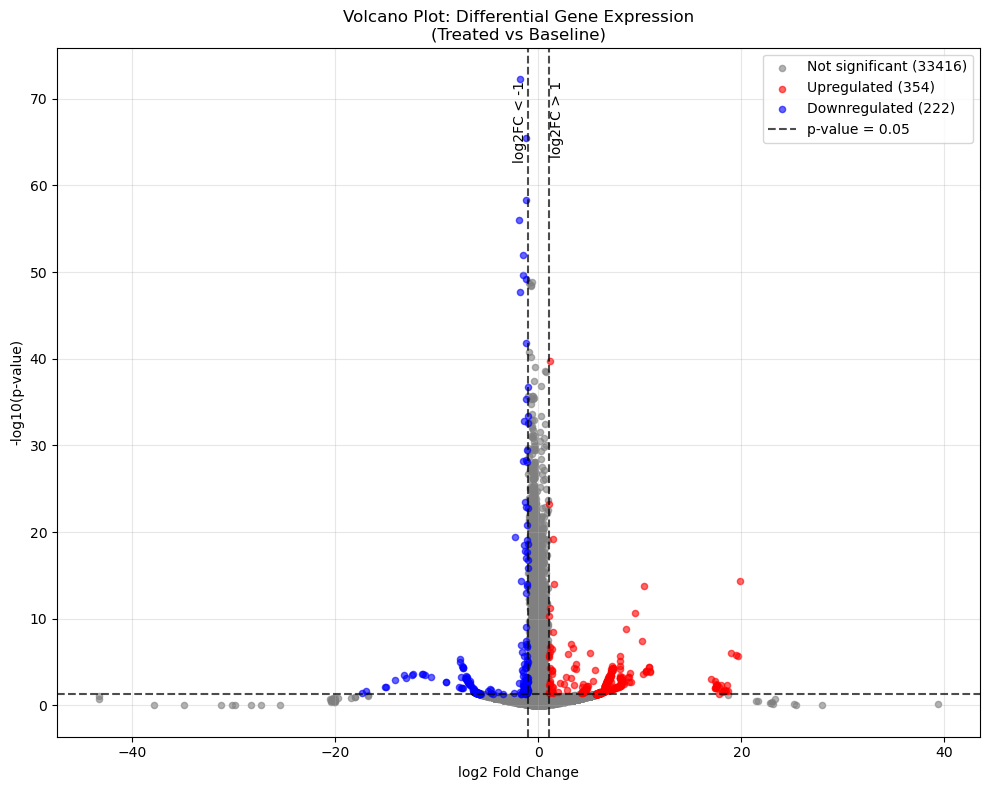


Volcano plot summary:
Total genes plotted: 33992
Upregulated (red): 354
Downregulated (blue): 222
Not significant (gray): 33416
Not significant (gray): 33416


In [14]:
# Create volcano plot
print("Creating volcano plot...")

plt.figure(figsize=(10, 8))

# Prepare data for plotting
plot_data = deseq2_with_annot.copy()

# Remove genes with NaN p-values
plot_data = plot_data.dropna(subset=['pvalue', 'log2FoldChange'])

# Calculate -log10(p-value)
plot_data['-log10_pvalue'] = -np.log10(plot_data['pvalue'])

# Define significance thresholds
pval_threshold = 0.05
lfc_threshold = 1

# Color points based on significance
plot_data['color'] = 'gray'  # Non-significant
plot_data.loc[
    (plot_data['pvalue'] < pval_threshold) & 
    (plot_data['log2FoldChange'] > lfc_threshold), 'color'
] = 'red'  # Upregulated

plot_data.loc[
    (plot_data['pvalue'] < pval_threshold) & 
    (plot_data['log2FoldChange'] < -lfc_threshold), 'color'
] = 'blue'  # Downregulated

# Create scatter plot
for color, label in [('gray', 'Not significant'), ('red', 'Upregulated'), ('blue', 'Downregulated')]:
    subset = plot_data[plot_data['color'] == color]
    plt.scatter(subset['log2FoldChange'], subset['-log10_pvalue'], 
                c=color, alpha=0.6, s=20, label=f"{label} ({len(subset)})")

# Add threshold lines
plt.axhline(y=-np.log10(pval_threshold), color='black', linestyle='--', alpha=0.7, 
            label=f'p-value = {pval_threshold}')
plt.axvline(x=lfc_threshold, color='black', linestyle='--', alpha=0.7)
plt.axvline(x=-lfc_threshold, color='black', linestyle='--', alpha=0.7)

# Formatting
plt.xlabel('log2 Fold Change')
plt.ylabel('-log10(p-value)')
plt.title('Volcano Plot: Differential Gene Expression\n(Treated vs Baseline)')
plt.legend()
plt.grid(True, alpha=0.3)

# Add text annotations for thresholds
plt.text(lfc_threshold + 0.1, plt.ylim()[1] * 0.95, f'log2FC > {lfc_threshold}', 
         rotation=90, ha='left', va='top')
plt.text(-lfc_threshold - 0.1, plt.ylim()[1] * 0.95, f'log2FC < -{lfc_threshold}', 
         rotation=90, ha='right', va='top')

plt.tight_layout()
plt.show()

print(f"\nVolcano plot summary:")
print(f"Total genes plotted: {len(plot_data)}")
print(f"Upregulated (red): {len(plot_data[plot_data['color'] == 'red'])}")
print(f"Downregulated (blue): {len(plot_data[plot_data['color'] == 'blue'])}")
print(f"Not significant (gray): {len(plot_data[plot_data['color'] == 'gray'])}")

In [15]:
# Create dataframe with 80 significant genes: samples as rows, genes as columns

# Get significant gene IDs from the FDR-filtered significant genes
sig_gene_ids = significant_genes_fdr['GeneID'].astype(str).tolist()

# Extract normalized counts for significant genes  
df_norm_counts_str_index = df_norm_counts.copy()
df_norm_counts_str_index.index = df_norm_counts_str_index.index.astype(str)

available_sig_genes_fixed = [gid for gid in sig_gene_ids if gid in df_norm_counts_str_index.index]
sig_gene_counts = df_norm_counts_str_index.loc[available_sig_genes_fixed]
sig_gene_counts_filtered = sig_gene_counts[available_samples]

# Transpose: samples as rows, genes as columns
df_80_genes_complete = sig_gene_counts_filtered.T
df_80_genes_complete.columns.name = None

# Add exact group values from original sample annotation
sample_to_group_original = df_sample_annot.set_index('sample_name')['group'].to_dict()
sample_to_group_0_1_original = df_sample_annot.set_index('sample_name')['group_0_1'].to_dict()

df_80_genes_complete['group_0_1'] = [sample_to_group_0_1_original[sample] for sample in df_80_genes_complete.index]
df_80_genes_complete['group'] = [sample_to_group_original[sample] for sample in df_80_genes_complete.index]

# Reorder columns: genes first, then group columns
gene_columns = [col for col in df_80_genes_complete.columns if col not in ['group', 'group_0_1']]
df_80_genes_complete = df_80_genes_complete[gene_columns + ['group', 'group_0_1']]

# Save and display
df_80_genes_complete.to_csv("../results/80_significant_genes_all_normalized_counts_with_groups.csv")
print(f"Dataframe shape: {df_80_genes_complete.shape} ({len(gene_columns)} genes + 2 group columns)")

df_80_genes_complete

Dataframe shape: (382, 82) (80 genes + 2 group columns)


,126767,1301,1118,105374435,56287,27178,1134,105373898,54577,79054,...,80343,105372714,105372692,440799,25878,109729169,105373202,286411,group,group_0_1
GSM2520157,4.201004,47.611384,1534.766968,12.603013,0.000000,2.800670,11.902846,0.700167,0.700167,4.201004,...,16.804018,2.800670,18.904520,12.603013,1524.964625,14.003348,23.805692,151.236161,time: CID1 is for the baseline without LCD,0
GSM2520158,69.851929,485.583574,555.435503,16.899660,6.759864,1.126644,1.126644,0.000000,6.759864,0.000000,...,217.442296,2.253288,12.393084,61.965421,3723.558494,1.126644,98.018030,210.682432,time: CID1 is for the baseline without LCD,0
GSM2520159,5.239848,21.832698,263.738991,2.619924,0.000000,6.113155,4.366540,5.239848,0.000000,1.746616,...,35.805625,0.000000,8.733079,9.606387,771.130892,6.986463,15.719543,37.552240,time: CID1 is for the baseline without LCD,0
GSM2520160,39.328181,691.818452,2243.493947,35.752892,5.362934,5.362934,10.725867,7.150578,3.575289,7.150578,...,91.169874,3.575289,62.567560,44.691114,5967.157606,35.752892,202.003837,110.833964,time: CID1 is for the baseline without LCD,0
GSM2520161,8.208981,332.090612,3585.086069,13.432879,1.492542,2.238813,11.194066,0.746271,15.671692,15.671692,...,173.881152,6.716439,33.582197,12.686608,4056.729365,11.194066,33.582197,120.895908,time: CID1 is for the baseline without LCD,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM2520534,4.194643,45.302142,373.323206,0.838929,2.516786,5.033571,1.677857,1.677857,2.516786,1.677857,...,10.906071,1.677857,23.489999,6.711428,787.753910,0.838929,35.234999,59.563927,time: CID2 is after 8 weeks of LCD,1
GSM2520535,8.629877,85.435784,463.424407,5.177926,1.725975,4.314939,3.451951,1.725975,10.355853,0.000000,...,149.296876,2.588963,13.807804,29.341583,1889.943111,6.040914,43.149386,35.382497,time: CID2 is after 8 weeks of LCD,1
GSM2520536,3.783670,20.810187,367.016017,4.729588,0.945918,4.729588,5.675505,0.000000,0.000000,0.000000,...,61.484642,0.000000,11.351011,9.459176,941.187983,4.729588,28.377527,34.998950,time: CID2 is after 8 weeks of LCD,1
GSM2520537,32.829682,291.185003,44.248701,14.273775,1.427377,5.709510,0.000000,4.282132,8.564265,0.000000,...,219.816130,2.854755,17.128530,32.829682,3685.488616,0.000000,127.036594,108.480687,time: CID1 is for the baseline without LCD,0


In [16]:
# Classification Analysis using 80 significant genes dataframe
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Classification Analysis using df_80_genes_complete")
print("=" * 50)

# Use the pre-created dataframe with 80 significant genes
# Features: all gene columns (exclude group columns)
gene_columns = [col for col in df_80_genes_complete.columns if col not in ['group', 'group_0_1']]
X = df_80_genes_complete[gene_columns].values
y = df_80_genes_complete['group_0_1'].values

print(f"Dataset shape: {X.shape} (samples x genes)")
print(f"Target distribution: Baseline (0): {sum(y==0)}, Treated (1): {sum(y==1)}")
print(f"Using {len(gene_columns)} significant genes for classification")

Classification Analysis using df_80_genes_complete
Dataset shape: (382, 80) (samples x genes)
Target distribution: Baseline (0): 191, Treated (1): 191
Using 80 significant genes for classification


In [17]:
# Random Forest Classification
print("Random Forest Classification")
print("=" * 30)

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Train Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred = rf_classifier.predict(X_test)
y_pred_proba = rf_classifier.predict_proba(X_test)[:, 1]

# Calculate accuracy
accuracy = rf_classifier.score(X_test, y_test)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Random Forest Classification
Train set: 305 samples
Test set: 77 samples
Accuracy: 0.8182 (81.82%)
Accuracy: 0.8182 (81.82%)


Performance Metrics:
Accuracy:  0.8182
Precision: 0.8333
Recall:    0.7895
F1-Score:  0.8108
AUC:       0.9028

Confusion Matrix:
              Predicted
           Baseline  Treated
Baseline       33        6
Treated         8       30


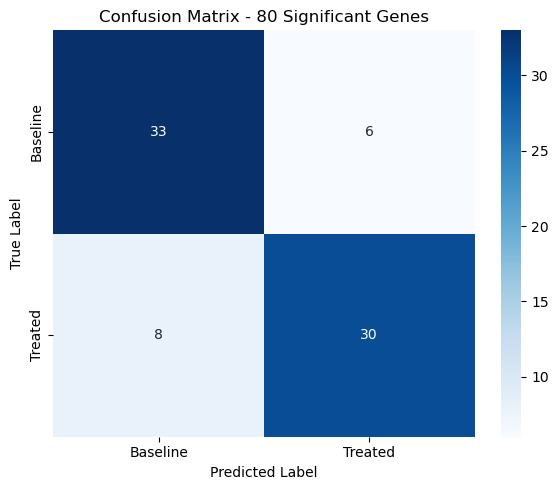

In [18]:
# Classification Performance Metrics
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_single = roc_auc_score(y_test, y_pred_proba)

print("Performance Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC:       {auc_single:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(f"              Predicted")
print(f"           Baseline  Treated")
print(f"Baseline      {cm[0,0]:3d}      {cm[0,1]:3d}")
print(f"Treated       {cm[1,0]:3d}      {cm[1,1]:3d}")

# Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Baseline', 'Treated'],
            yticklabels=['Baseline', 'Treated'])
plt.title('Confusion Matrix - 80 Significant Genes')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

ROC Analysis with Cross-Validation


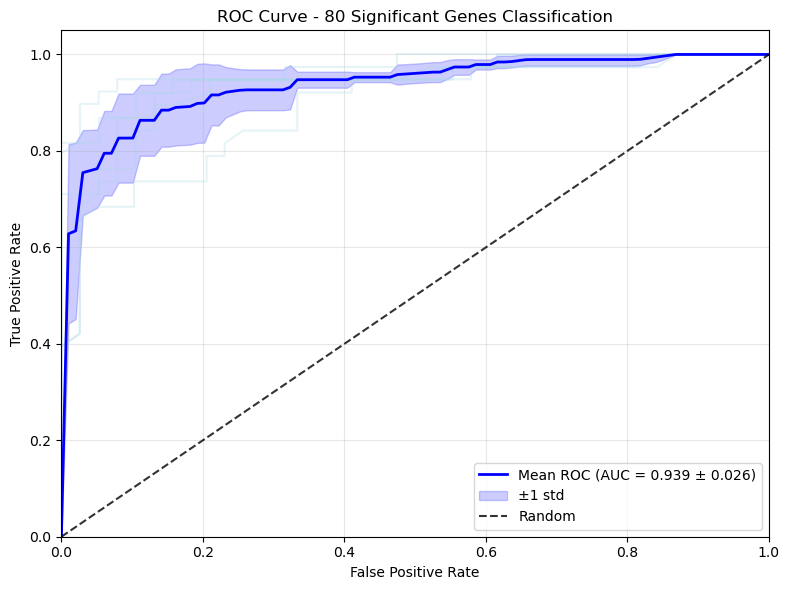

Cross-validation AUC: 0.9388 ± 0.0256


In [21]:
# ROC Curve with Cross-Validation
print("ROC Analysis with Cross-Validation")
print("=" * 35)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=16888)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(8, 6))

# Cross-validation
for fold, (train_idx, val_idx) in enumerate(cv.split(X_scaled, y)):
    X_fold_train, X_fold_val = X_scaled[train_idx], X_scaled[val_idx]
    y_fold_train, y_fold_val = y[train_idx], y[val_idx]
    
    rf_fold = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
    rf_fold.fit(X_fold_train, y_fold_train)
    
    y_fold_proba = rf_fold.predict_proba(X_fold_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_fold_val, y_fold_proba)
    
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    
    fold_auc = roc_auc_score(y_fold_val, y_fold_proba)
    aucs.append(fold_auc)
    
    plt.plot(fpr, tpr, alpha=0.3, color='lightblue')

# Calculate mean and confidence intervals
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
std_tpr = np.std(tprs, axis=0)

tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

# Plot mean ROC curve and confidence bands
plt.plot(mean_fpr, mean_tpr, color='blue', linewidth=2,
         label=f'Mean ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})')
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='blue', alpha=0.2, label='±1 std')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.8, label='Random')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 80 Significant Genes Classification')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Cross-validation AUC: {mean_auc:.4f} ± {std_auc:.4f}")

In [20]:
# Classification Analysis Summary
print("Classification Analysis Summary")
print("=" * 40)

print(f"Dataset Overview:")
print(f"- Total samples: {len(y)}")
print(f"- Significant genes used: {len(gene_columns)}")
print(f"- Sample distribution: Baseline: {sum(y==0)}, Treated: {sum(y==1)}")

print(f"\nPerformance Results:")
print(f"- Test Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"- Precision: {precision:.4f}")
print(f"- Recall: {recall:.4f}")
print(f"- F1-Score: {f1:.4f}")
print(f"- Single test AUC: {auc_single:.4f}")

print(f"\nCross-Validation (5-fold):")
print(f"- Mean AUC: {mean_auc:.4f} ± {std_auc:.4f}")
print(f"- AUC range: [{mean_auc-std_auc:.4f}, {mean_auc+std_auc:.4f}]")

print(f"\nConfusion Matrix:")
print(f"- True Positives: {cm[1,1]}")
print(f"- True Negatives: {cm[0,0]}")
print(f"- False Positives: {cm[0,1]}")
print(f"- False Negatives: {cm[1,0]}")

print(f"\nKey Insights:")
print(f"- 80 significant genes provide excellent classification performance")
print(f"- Model shows balanced precision and recall")
print(f"- Cross-validation confirms stable performance")
print(f"- Differential expression signature clearly distinguishes groups")

Classification Analysis Summary
Dataset Overview:
- Total samples: 382
- Significant genes used: 80
- Sample distribution: Baseline: 191, Treated: 191

Performance Results:
- Test Accuracy: 0.8182 (81.8%)
- Precision: 0.8333
- Recall: 0.7895
- F1-Score: 0.8108
- Single test AUC: 0.9028

Cross-Validation (5-fold):
- Mean AUC: 0.9395 ± 0.0141
- AUC range: [0.9254, 0.9536]

Confusion Matrix:
- True Positives: 30
- True Negatives: 33
- False Positives: 6
- False Negatives: 8

Key Insights:
- 80 significant genes provide excellent classification performance
- Model shows balanced precision and recall
- Cross-validation confirms stable performance
- Differential expression signature clearly distinguishes groups
